In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [ ]:
(train_ds, test_ds), ds_info = tfds.load('cats_vs_dogs',
                                         split = ['train[:80%]','train[:20%]'],
                                         as_supervised=True,
                                         with_info=True)

def preprocess(image, label):
    image = tf.cast(image, tf.float32)/255.0
    image = tf.image.resize(image, (128,128))
    return image, label

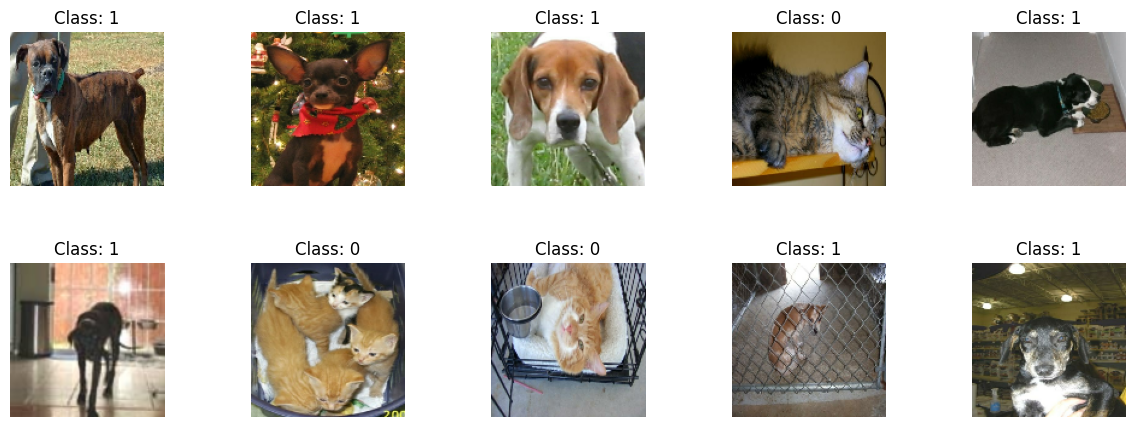

In [ ]:
train_ds_mapped = train_ds.map(preprocess)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

# Sử dụng .take(10) để lấy 10 mẫu từ dataset
for i, (image, label) in enumerate(train_ds_mapped.take(10)):
    ax[i].imshow(image)
    ax[i].set_title(f'Class: {label.numpy()}')
    ax[i].axis('off')

plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,329 (49.36 MB)

 Trainable params: 12,939,329 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BATCH_SIZE = 32

# Chuẩn bị dữ liệu từ dataset có sẵn
train_ds_final = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds_final = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Biên dịch lại với loss phù hợp cho phân loại nhị phân
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện sử dụng dataset thay vì X_train, y_train
model_fit = model.fit(
    train_ds_final,
    epochs=15,
    validation_data=test_ds_final,
    verbose=1
)

Epoch 1/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.6387 - loss: 0.6291 - val_accuracy: 0.7201 - val_loss: 0.5383
Epoch 2/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.7605 - loss: 0.4937 - val_accuracy: 0.8022 - val_loss: 0.4258
Epoch 3/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.8130 - loss: 0.4109 - val_accuracy: 0.8212 - val_loss: 0.3692
Epoch 4/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.8588 - loss: 0.3191 - val_accuracy: 0.8727 - val_loss: 0.2997
Epoch 5/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.9017 - loss: 0.2328 - val_accuracy: 0.9052 - val_loss: 0.2365
Epoch 6/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.9266 - loss: 0.1817 - val_accuracy: 0.9200 - val_loss: 0.2074
Epoch 7/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9505 - loss: 0.1272 - val_accuracy: 0.9469 - val_loss: 0.1453
Epoch 8/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9729 - loss: 0.0750 - 

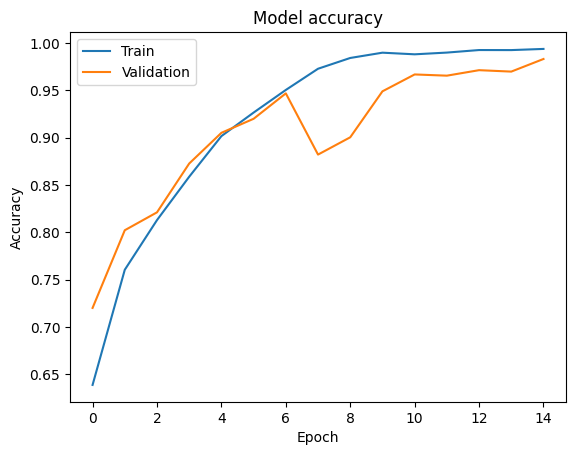

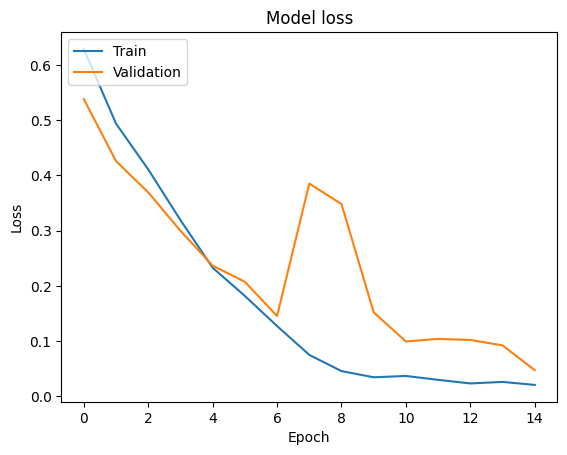

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Đánh giá mô hình sử dụng test_ds_final
score = model.evaluate(test_ds_final, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

146/146 - 5s - 36ms/step - accuracy: 0.9832 - loss: 0.0472
Test loss: 0.04722880199551582
Test accuracy: 0.9832330346107483


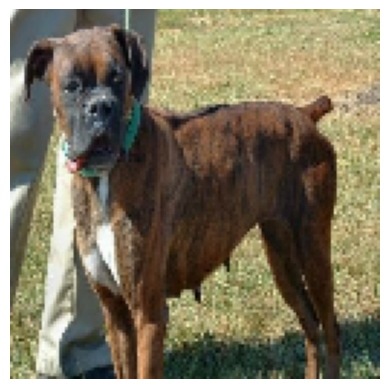

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Giá trị dự đoán (Raw): 1.0000
Kết quả dự đoán: Chó
Thực tế: Chó


In [ ]:
# Lấy 1 batch từ tập test
for images, labels in test_ds_final.take(1):
    sample_image = images[0]
    sample_label = labels[0]

# Hiển thị ảnh
plt.imshow(sample_image)
plt.axis('off')
plt.show()

# Dự đoán
prediction = model.predict(tf.expand_dims(sample_image, axis=0))
pred_class = "Chó" if prediction[0] > 0.5 else "Mèo"
actual_class = "Chó" if sample_label == 1 else "Mèo"

print(f"Giá trị dự đoán (Raw): {prediction[0][0]:.4f}")
print(f"Kết quả dự đoán: {pred_class}")
print(f"Thực tế: {actual_class}")

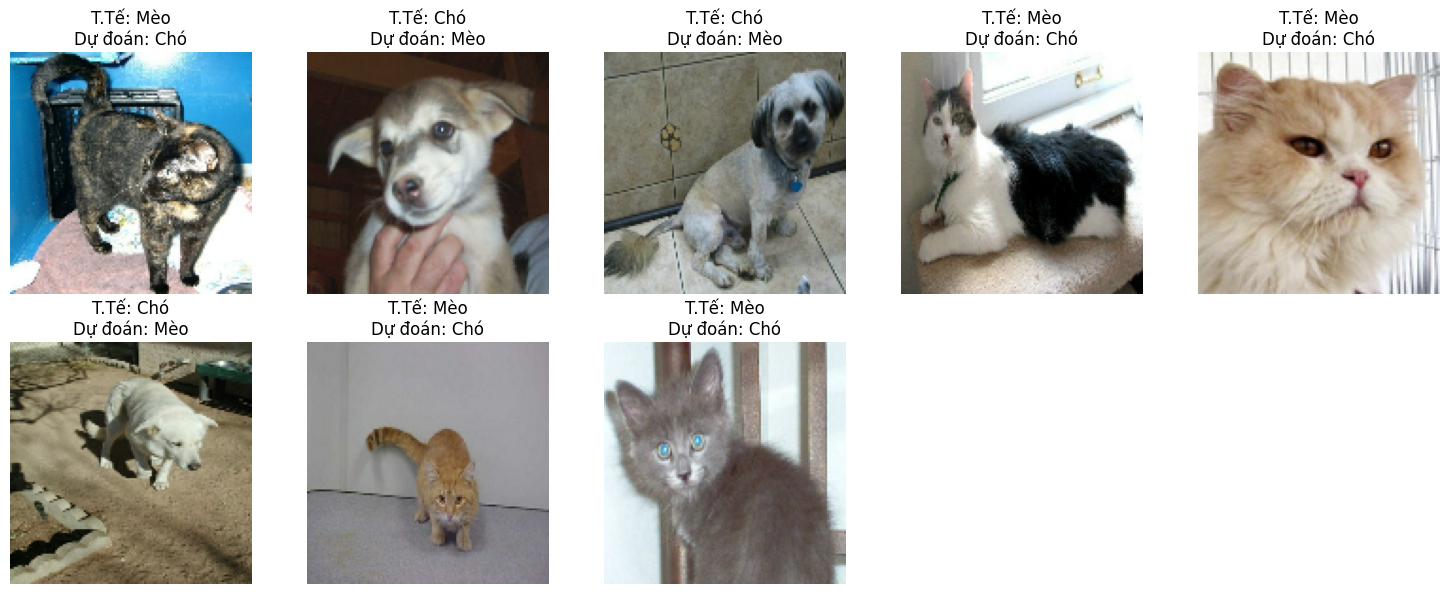

In [ ]:
misclassified_images = []
misclassified_labels = []
predicted_labels = []

# Duyệt qua tập test (lấy tối đa 500 ảnh để kiểm tra nhanh)
for images, labels in test_ds_final.take(20):
    preds = model.predict(images, verbose=0)
    preds_binary = (preds > 0.5).astype(int).flatten()
    labels_np = labels.numpy()

    for i in range(len(labels_np)):
        if preds_binary[i] != labels_np[i]:
            misclassified_images.append(images[i])
            misclassified_labels.append(labels_np[i])
            predicted_labels.append(preds_binary[i])
        if len(misclassified_images) >= 100: # Dừng khi tìm thấy 10 ảnh sai
            break
    if len(misclassified_images) >= 100:
        break

# Hiển thị các ảnh sai
if misclassified_images:
    plt.figure(figsize=(15, 6))
    for i in range(len(misclassified_images)):
        plt.subplot(2, 5, i + 1)
        plt.imshow(misclassified_images[i])
        actual = "Chó" if misclassified_labels[i] == 1 else "Mèo"
        pred = "Chó" if predicted_labels[i] == 1 else "Mèo"
        plt.title(f"T.Tế: {actual}\nDự đoán: {pred}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy hình ảnh nào bị dự đoán sai trong số các mẫu đã kiểm tra.")